# Raw CSV Feature Audit: Events and Usage

This notebook performs a complete feature-level analysis of:
- `data/raw/sample_instance_events.csv`
- `data/raw/sample_instance_usage.csv`

It covers:
1. Dataset shape and preview
2. Column-by-column schema and missingness
3. Full distinct values for each feature (saved to files)
4. Frequency tables for low-cardinality features
5. Numeric distribution summaries

In [14]:
from pathlib import Path
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.width', 180)

RAW_DIR = Path('../data/raw')
OUT_DIR = Path('../data/processed/feature_audit')
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'events': RAW_DIR / 'sample_instance_events_forced.csv',
    'usage': RAW_DIR / 'sample_instance_usage_forced.csv',
}

dfs = {name: pd.read_csv(path) for name, path in DATASETS.items()}

for name, df in dfs.items():
    print(f"{name}: shape={df.shape}, file={DATASETS[name]}")
    display(df.head(5))

events: shape=(844844, 6), file=../data/raw/sample_instance_events_forced.csv


,collection_id,priority,scheduling_class,resource_request_cpus,resource_request_ram,machine_id
0,385223982662,0,0,0.003345,0.001711,NaN
1,380762246352,107,1,0.024750,0.002476,NaN
2,395296320970,0,1,0.008362,0.001221,NaN
3,378253165591,0,0,0.004753,0.005501,NaN
4,383069141836,107,1,0.002026,0.001774,NaN


usage: shape=(45860944, 5), file=../data/raw/sample_instance_usage_forced.csv


,collection_id,start_time,end_time,average_usage_cpus,average_usage_memory
0,385223982662,206700000000,207000000000,0.000168,3.597260e-03
1,380762246352,78416000000,78417000000,0.000000,0.000000e+00
2,395296320970,686953000000,686954000000,0.000000,9.536743e-07
3,378253165591,821267000000,821270000000,0.000147,1.335144e-04
4,383069141836,680382000000,680400000000,0.000918,6.093979e-04


In [15]:
def feature_profile(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    n = len(df)
    for col in df.columns:
        s = df[col]
        non_null = int(s.notna().sum())
        nulls = int(s.isna().sum())
        nunique = int(s.nunique(dropna=True))
        rows.append(
            {
                'column': col,
                'dtype': str(s.dtype),
                'rows': n,
                'non_null': non_null,
                'nulls': nulls,
                'null_pct': (nulls / n) * 100 if n else np.nan,
                'unique_non_null_values': nunique,
                'is_numeric': pd.api.types.is_numeric_dtype(s),
            }
        )
    return pd.DataFrame(rows).sort_values(['is_numeric', 'unique_non_null_values', 'column'], ascending=[False, False, True]).reset_index(drop=True)

profiles = {name: feature_profile(df) for name, df in dfs.items()}

for name, profile in profiles.items():
    print(f"\n=== {name.upper()} FEATURE PROFILE ===")
    display(profile)


=== EVENTS FEATURE PROFILE ===


,column,dtype,rows,non_null,nulls,null_pct,unique_non_null_values,is_numeric
0,machine_id,float64,844844,19511,825333,97.690580,7563,True
1,resource_request_ram,float64,844844,844649,195,0.023081,3796,True
2,collection_id,int64,844844,844844,0,0.000000,2000,True
3,resource_request_cpus,float64,844844,844649,195,0.023081,1748,True
4,priority,int64,844844,844844,0,0.000000,11,True
5,scheduling_class,int64,844844,844844,0,0.000000,4,True



=== USAGE FEATURE PROFILE ===


,column,dtype,rows,non_null,nulls,null_pct,unique_non_null_values,is_numeric
0,start_time,int64,45860944,45860944,0,0.0,1084025,True
1,end_time,int64,45860944,45860944,0,0.0,1046816,True
2,average_usage_cpus,float64,45860944,45860944,0,0.0,5446,True
3,average_usage_memory,float64,45860944,45860944,0,0.0,3844,True
4,collection_id,int64,45860944,45860944,0,0.0,1977,True


In [4]:
def distinct_values_table(series: pd.Series) -> pd.DataFrame:
    vc = series.value_counts(dropna=False)
    out = vc.reset_index()
    out.columns = ['value', 'count']
    out['pct'] = (out['count'] / len(series)) * 100
    # Normalize value to string for robust CSV export and easier visual inspection.
    out['value_repr'] = out['value'].map(lambda x: '<NA>' if pd.isna(x) else str(x))
    return out[['value', 'value_repr', 'count', 'pct']]

all_distinct_tables = {}

for ds_name, df in dfs.items():
    ds_dir = OUT_DIR / ds_name
    ds_dir.mkdir(parents=True, exist_ok=True)
    all_distinct_tables[ds_name] = {}

    for col in df.columns:
        table = distinct_values_table(df[col])
        all_distinct_tables[ds_name][col] = table

        out_path = ds_dir / f"{col}__distinct_values.csv"
        table.to_csv(out_path, index=False)

    print(f"Saved full distinct-value tables for {ds_name} in: {ds_dir}")

Saved full distinct-value tables for events in: ../data/processed/feature_audit/events
Saved full distinct-value tables for usage in: ../data/processed/feature_audit/usage


In [5]:
# Display complete value frequencies for low-cardinality columns.
LOW_CARDINALITY_THRESHOLD = 60

for ds_name, df in dfs.items():
    print(f"\n=== {ds_name.upper()} LOW-CARDINALITY FEATURES (<= {LOW_CARDINALITY_THRESHOLD} unique values) ===")
    profile = profiles[ds_name]
    low_card_cols = profile.loc[profile['unique_non_null_values'] <= LOW_CARDINALITY_THRESHOLD, 'column'].tolist()

    if not low_card_cols:
        print('No low-cardinality columns found.')
        continue

    for col in low_card_cols:
        print(f"\n--- {col} ---")
        display(all_distinct_tables[ds_name][col])


=== EVENTS LOW-CARDINALITY FEATURES (<= 60 unique values) ===

--- priority ---


,value,value_repr,count,pct
0,0,0,9094,90.94
1,200,200,511,5.11
2,103,103,181,1.81
3,105,105,60,0.60
4,107,107,51,0.51
5,25,25,40,0.40
6,119,119,25,0.25
7,210,210,15,0.15
8,101,101,9,0.09
9,115,115,7,0.07



--- scheduling_class ---


,value,value_repr,count,pct
0,0,0,7832,78.32
1,2,2,1734,17.34
2,1,1,398,3.98
3,3,3,36,0.36



=== USAGE LOW-CARDINALITY FEATURES (<= 60 unique values) ===
No low-cardinality columns found.


In [6]:
# Numeric summary for all numeric features (distribution-friendly stats).
for ds_name, df in dfs.items():
    num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    print(f"\n=== {ds_name.upper()} NUMERIC SUMMARY ===")
    if not num_cols:
        print('No numeric columns found.')
        continue

    summary = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
    summary['nulls'] = df[num_cols].isna().sum()
    summary['null_pct'] = (summary['nulls'] / len(df)) * 100
    display(summary)

# Optional: inspect one high-cardinality column at a time with full frequency table.
# Example:
# display(all_distinct_tables['usage']['start_time'])


=== EVENTS NUMERIC SUMMARY ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,nulls,null_pct
collection_id,10000.0,3.302564e+11,1.223754e+11,4.142189e+09,3.951699e+10,3.951700e+10,3.744715e+11,3.813077e+11,3.840762e+11,3.979865e+11,3.997551e+11,4.004619e+11,0,0.00
priority,10000.0,1.422570e+01,4.785888e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+02,2.000000e+02,2.100000e+02,0,0.00
scheduling_class,10000.0,3.974000e-01,7.797012e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,0,0.00
resource_request_cpus,9986.0,8.010452e-03,5.984308e-03,0.000000e+00,0.000000e+00,1.863003e-03,3.238678e-03,4.051208e-03,1.417542e-02,1.620483e-02,2.026367e-02,8.630371e-02,14,0.14
resource_request_ram,9986.0,2.990749e-03,1.413807e-03,0.000000e+00,0.000000e+00,2.059937e-04,1.953125e-03,3.906250e-03,3.906250e-03,3.906250e-03,3.906250e-03,3.906250e-03,14,0.14
machine_id,444.0,6.078501e+10,9.580927e+10,2.073360e+07,2.073690e+07,2.127117e+07,1.578714e+09,2.362447e+10,9.203712e+10,3.575159e+11,3.764942e+11,3.839358e+11,9556,95.56



=== USAGE NUMERIC SUMMARY ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,nulls,null_pct
collection_id,50000.0,2.263241e+11,1.268798e+11,277.0,4.422663e+09,6.548250e+09,1.056218e+11,2.205859e+11,3.305873e+11,3.817401e+11,3.945132e+11,4.002604e+11,0,0.0
start_time,50000.0,1.338786e+12,7.862192e+11,300000000.0,2.820000e+10,1.245000e+11,6.534000e+11,1.341600e+12,2.015100e+12,2.565600e+12,2.661977e+12,2.678873e+12,0,0.0
end_time,50000.0,1.339028e+12,7.862190e+11,600000000.0,2.850000e+10,1.247872e+11,6.537000e+11,1.341900e+12,2.015158e+12,2.565900e+12,2.662203e+12,2.679000e+12,0,0.0
average_usage_cpus,50000.0,6.496786e-03,1.370868e-02,0.0,0.000000e+00,0.000000e+00,1.993179e-04,4.768372e-04,8.270264e-03,3.030396e-02,4.534973e-02,3.378906e-01,0,0.0
average_usage_memory,50000.0,3.800764e-03,6.597427e-03,0.0,0.000000e+00,9.536743e-07,2.059937e-04,5.474091e-04,4.793167e-03,1.870728e-02,2.481140e-02,8.398438e-02,0,0.0


## Static Batch EDA: Workload, Mechanism, and Costs

This section analyzes `data/processed/static_batch_may2019.csv` to validate:
1. Heavy-tailed workload physics and overprovisioning
2. Valuation/virtual-value behavior from mechanism design
3. Energy and cost relationships before dynamic grid integration

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

PROCESSED_PATH = Path('../data/processed/static_batch_may2019.csv')
processed_df = pd.read_csv(PROCESSED_PATH)

print(f"Loaded processed dataset: {PROCESSED_PATH}")
print(f"Shape: {processed_df.shape}")
display(processed_df.head(5))

duration_col = 'D' if 'D' in processed_df.columns else 'D (hours)'
if duration_col not in processed_df.columns:
    raise ValueError("Expected a duration column named 'D' or 'D (hours)'.")

required_cols = [
    'A_cpu', 'A_ram', duration_col, 'actual_cpu_usage',
    'v', 'phi_v', 'w_j_kw', 'C_elec', 'C_carbon'
 ]
missing_cols = [c for c in required_cols if c not in processed_df.columns]
if missing_cols:
    raise ValueError(f"Missing expected columns in processed dataset: {missing_cols}")
print(f"Using duration column: {duration_col}")

Loaded processed dataset: ../data/processed/static_batch_may2019.csv
Shape: (1977, 14)


,collection_id,job_datetime,A_cpu,A_ram,actual_cpu_usage,actual_ram_usage,D (hours),v,phi_v,w_j_kw,elec_price_per_kWh,carbon_intensity_gCO2_per_kWh,C_elec,C_carbon
0,383044398050,2019-05-01 00:05:00,4.267406,3.071987,0.001084,0.006884,744.083333,1196.241801,846.428018,0.020466,0.031366,330.784619,0.477660,251.868362
1,384666769426,2019-05-01 00:05:00,0.008453,0.006508,0.000106,0.000007,744.083333,1.681407,0.936785,0.000041,0.031366,330.784619,0.000952,0.501790
2,396353658785,2019-05-01 00:05:00,0.010746,0.003819,0.000238,0.003544,744.083333,0.427098,-5.555512,0.000049,0.031366,330.784619,0.001153,0.607730
3,381581703409,2019-05-01 00:05:00,11.200719,8.019781,0.000091,0.000449,744.083333,1822.563018,800.446152,0.053694,0.031366,330.784619,1.253164,660.789285
4,400258011113,2019-05-01 00:05:00,1.375648,1.788795,0.000549,0.000438,744.083333,271.512665,93.449582,0.007037,0.031366,330.784619,0.164229,86.597502


Using duration column: D (hours)


/Users/francescodangolo/Projects/cloud_pricing_sim/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/francescodangolo/Projects/cloud_pricing_sim/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


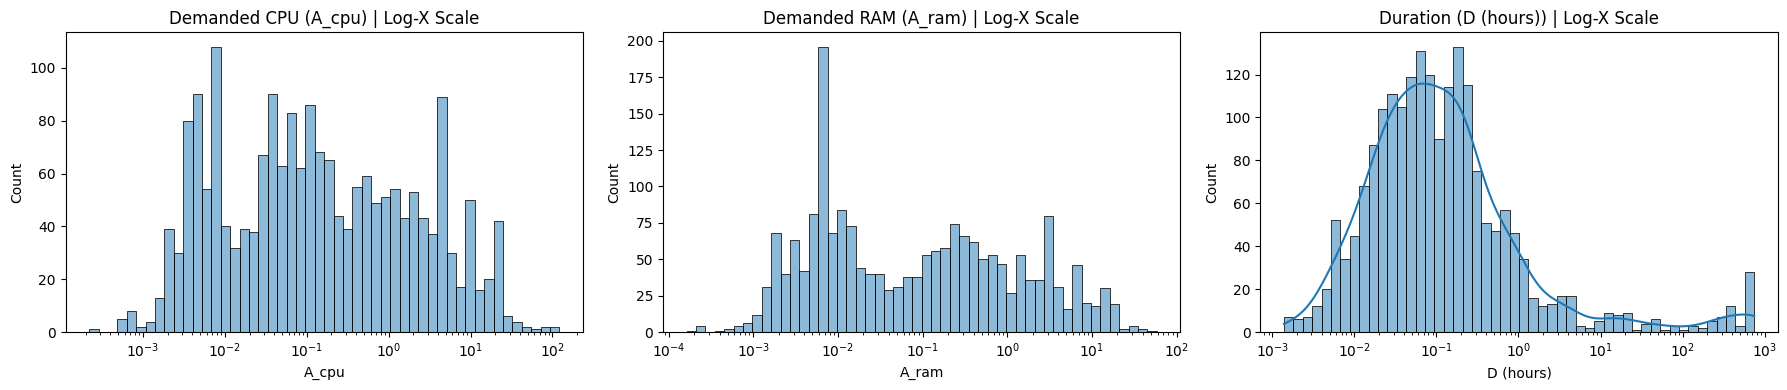

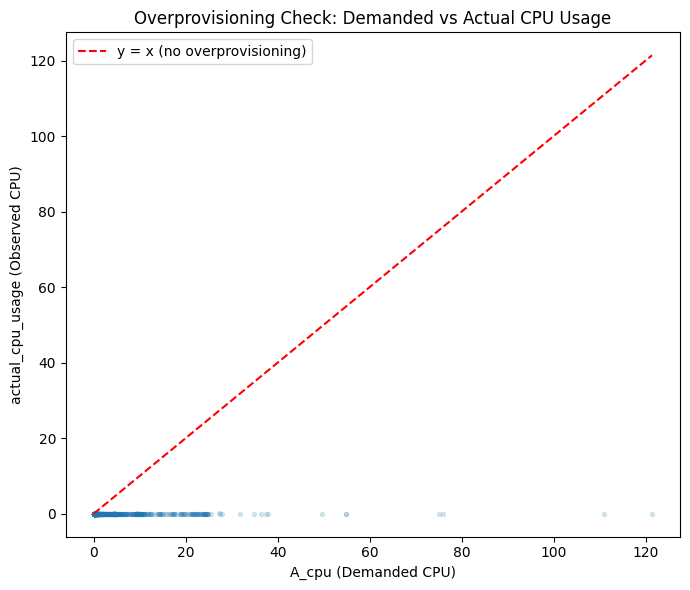

Share of jobs with actual_cpu_usage < A_cpu: 89.48%


In [ ]:
# 1) Workload Physics: heavy tails + overprovisioning
feature_cols = ['A_cpu', 'A_ram', duration_col]
feature_titles = [
    'Demanded CPU (A_cpu)',
    'Demanded RAM (A_ram)',
    f'Duration ({duration_col})',
]

# Linear-scale histograms (direct magnitude comparison).
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(axes, feature_cols, feature_titles):
    sns.histplot(processed_df[col].dropna(), kde=True, ax=ax, bins=50)
    ax.set_title(f'{title} | Linear Scale')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

# Log-scale histograms (tail/shape visibility across orders of magnitude).
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for ax, col, title in zip(axes, feature_cols, feature_titles):
    sns.histplot(processed_df[col].dropna(), kde=True, log_scale=True, ax=ax, bins=50)
    ax.set_title(f'{title} | Log-X Scale')
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
scatter_df = processed_df[['A_cpu', 'actual_cpu_usage']].dropna()
sns.scatterplot(
    data=scatter_df.sample(n=min(15000, len(scatter_df)), random_state=42),
    x='A_cpu',
    y='actual_cpu_usage',
    alpha=0.2,
    s=12,
    edgecolor=None,
 )

max_axis = float(np.nanmax([scatter_df['A_cpu'].max(), scatter_df['actual_cpu_usage'].max()]))
plt.plot([0, max_axis], [0, max_axis], linestyle='--', color='red', label='y = x (no overprovisioning)')
plt.title('Overprovisioning Check: Demanded vs Actual CPU Usage')
plt.xlabel('A_cpu (Demanded CPU)')
plt.ylabel('actual_cpu_usage (Observed CPU)')
plt.legend()
plt.tight_layout()
plt.show()

overprov_ratio = (
    (scatter_df['actual_cpu_usage'] < scatter_df['A_cpu']).mean()
    if len(scatter_df) else np.nan
 )
print(f"Share of jobs with actual_cpu_usage < A_cpu: {overprov_ratio:.2%}")

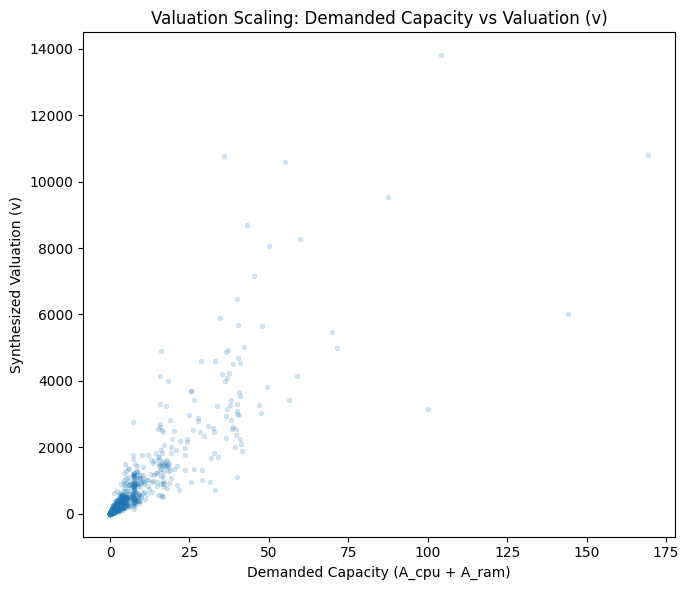

Pearson corr(demanded_capacity, v): 0.876


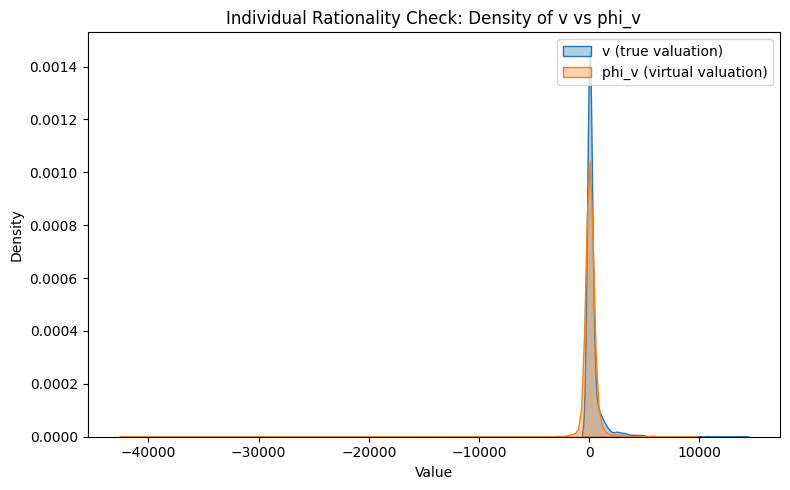

Optimal Auction Rejection Rate: 28.78%


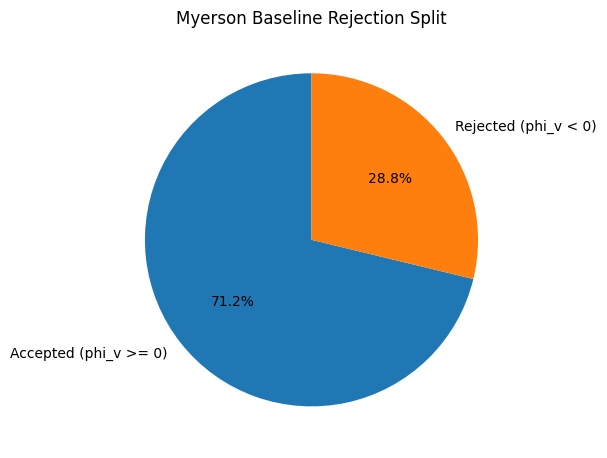

In [19]:
# 2) Economic Mechanism Design: valuations and virtual values
econ_df = processed_df[['A_cpu', 'A_ram', 'v', 'phi_v']].dropna().copy()
econ_df['demanded_capacity'] = econ_df['A_cpu'] + econ_df['A_ram']

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=econ_df.sample(n=min(15000, len(econ_df)), random_state=42),
    x='demanded_capacity',
    y='v',
    alpha=0.2,
    s=12,
    edgecolor=None,
 )
plt.title('Valuation Scaling: Demanded Capacity vs Valuation (v)')
plt.xlabel('Demanded Capacity (A_cpu + A_ram)')
plt.ylabel('Synthesized Valuation (v)')
plt.tight_layout()
plt.show()

corr_val = econ_df[['demanded_capacity', 'v']].corr().iloc[0, 1]
print(f"Pearson corr(demanded_capacity, v): {corr_val:.3f}")

plt.figure(figsize=(8, 5))
sns.kdeplot(econ_df['v'], fill=True, alpha=0.35, label='v (true valuation)')
sns.kdeplot(econ_df['phi_v'], fill=True, alpha=0.35, label='phi_v (virtual valuation)')
plt.title('Individual Rationality Check: Density of v vs phi_v')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

rejected = int((econ_df['phi_v'] < 0).sum())
accepted = int((econ_df['phi_v'] >= 0).sum())
rejection_rate = rejected / len(econ_df) if len(econ_df) else np.nan
print(f"Optimal Auction Rejection Rate: {rejection_rate:.2%}")

plt.figure(figsize=(6, 6))
plt.pie(
    [accepted, rejected],
    labels=['Accepted (phi_v >= 0)', 'Rejected (phi_v < 0)'],
    autopct='%1.1f%%',
    startangle=90,
 )
plt.title('Myerson Baseline Rejection Split')
plt.tight_layout()
plt.show()

/Users/francescodangolo/Projects/cloud_pricing_sim/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


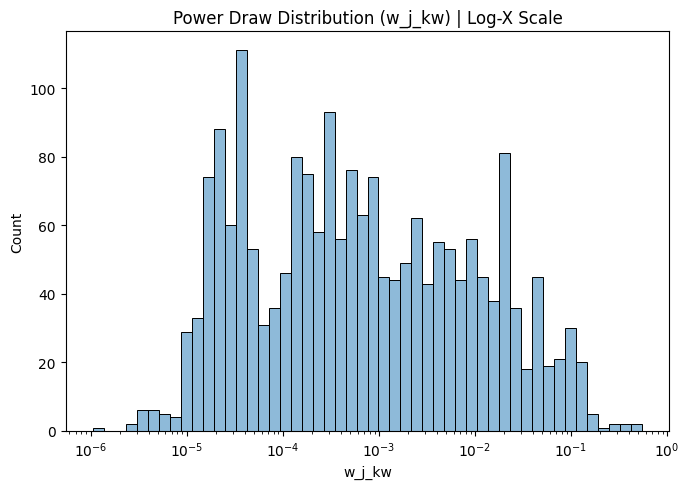

Top 5 jobs by w_j_kw:


,collection_id,A_cpu,A_ram,D (hours),w_j_kw,C_elec,C_carbon
625,377795153893,121.429860,22.678816,0.129722,0.546765,0.002198,1.165115
640,20129862094,110.981445,58.475098,0.144722,0.520480,0.001528,1.022182
1420,360937258671,75.949051,28.076309,0.001944,0.349618,0.000014,0.009305
467,397117467315,75.009096,12.601035,0.048611,0.336971,0.000364,0.230862
356,375078090986,54.914597,45.041492,0.002222,0.266397,0.000029,0.012469


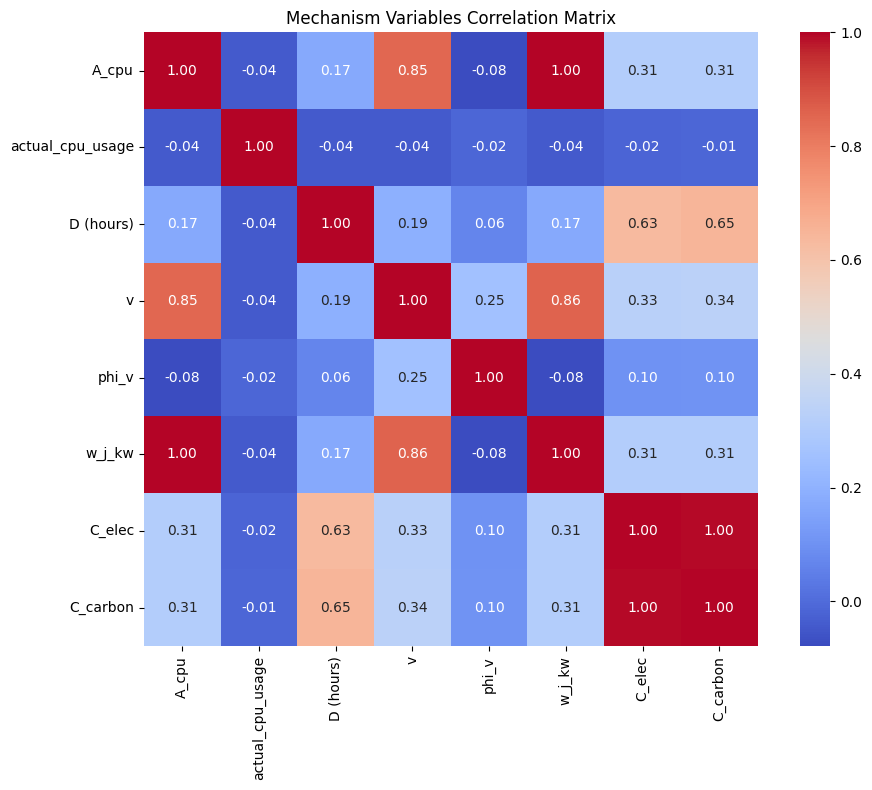

Optimal Auction Rejection Rate (full dataset): 28.78%
corr(C_elec, w_j_kw * duration): 0.9794
corr(C_carbon, w_j_kw * duration): 0.9944
corr(C_elec, C_carbon): 0.9953


In [20]:
# 3) Objective Costs: power profiling + correlation diagnostics
plt.figure(figsize=(7, 5))
sns.histplot(processed_df['w_j_kw'].dropna(), kde=True, log_scale=True, bins=50)
plt.title('Power Draw Distribution (w_j_kw) | Log-X Scale')
plt.xlabel('w_j_kw')
plt.tight_layout()
plt.show()

print('Top 5 jobs by w_j_kw:')
display(processed_df.nlargest(5, 'w_j_kw')[['collection_id', 'A_cpu', 'A_ram', duration_col, 'w_j_kw', 'C_elec', 'C_carbon']])

# Correlation Matrix (starter anomaly check)
cols = ['A_cpu', 'actual_cpu_usage', duration_col, 'v', 'phi_v', 'w_j_kw', 'C_elec', 'C_carbon']
corr = processed_df[cols].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Mechanism Variables Correlation Matrix')
plt.tight_layout()
plt.show()

# Rejection rate recap using the full processed dataset.
rejected_full = int((processed_df['phi_v'] < 0).sum())
print(f"Optimal Auction Rejection Rate (full dataset): {rejected_full / len(processed_df):.2%}")

# Static-grid consistency check: both costs should move together strongly.
proxy = processed_df['w_j_kw'] * processed_df[duration_col]
print(f"corr(C_elec, w_j_kw * duration): {processed_df['C_elec'].corr(proxy):.4f}")
print(f"corr(C_carbon, w_j_kw * duration): {processed_df['C_carbon'].corr(proxy):.4f}")
print(f"corr(C_elec, C_carbon): {processed_df['C_elec'].corr(processed_df['C_carbon']):.4f}")